In [21]:
import warnings, os, cv2, shutil, urllib.request

import numpy  as np
import pandas as pd
from tqdm                        import tqdm
from skimage.feature             import hog, local_binary_pattern
from skimage.exposure            import rescale_intensity
import mediapipe as mp
from mediapipe.tasks          import python as mp_python
from mediapipe.tasks.python   import vision as mp_vision

In [23]:
# ── Constants ────────────────────────────────────────
EMOTIONS = ["angry", "happy", "neutral", "sad", "surprise"]
IMG_SIZE = 48
TRAIN_DIR = "../data/train/"
TEST_DIR  = "../data/test/"

FEATURE_NAMES = (
    ["brightness_mean", "lower_edge_density"]
    + [f"hog_h{i:02d}" for i in range(16)]
    + [f"lbp_h{i:02d}" for i in range(6)]
    + [
        "ear_L", "ear_R",                         # F25–F26  eyes open/closed
        "brow_eye_L", "brow_eye_R",               # F27–F28  brow height above eye
        "inter_brow",                             # F29      brow pinch (angry)
        "brow_raise_L", "brow_raise_R",           # F30–F31  brow arch height
        "MAR",                                    # F32      mouth open ratio
        "lip_pull",                               # F33      smile width
        "lip_droop",                              # F34      corner droop (sad)
        "mouth_curl",                             # F35      curl up (happy)
        "lip_tight",                              # F36      pressed lips (angry)
        "jaw_open",                               # F37      jaw drop magnitude
        "cheek_L", "cheek_R",                     # F38–F39  cheek raise (happy)
        "nose_lip",                               # F40      nose-to-lip dist
        "face_AR",                                # F41      face aspect ratio
    ]
)  # total = 2 + 16 + 6 + 17 = 41
assert len(FEATURE_NAMES) == 41, f"Expected 41, got {len(FEATURE_NAMES)}"
print(f"Feature names: {len(FEATURE_NAMES)} total")
os.makedirs("output/01_features",  exist_ok=True)
os.makedirs("csv/",  exist_ok=True)

Feature names: 41 total


In [24]:
# ── MediaPipe FaceLandmarker ─────────
MODEL_PATH = "face_landmarker_models/face_landmarker.task"
MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/1/face_landmarker.task"
)

if not os.path.exists(MODEL_PATH):
    print(f"Downloading FaceLandmarker model → {MODEL_PATH} …")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"  Done  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")
else:
    print(f"Model found: {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")

_OPTIONS = mp_vision.FaceLandmarkerOptions(
    base_options                  = mp_python.BaseOptions(model_asset_path=MODEL_PATH),
    num_faces                     = 1,
    min_face_detection_confidence = 0.5,
    min_face_presence_confidence  = 0.5,
    min_tracking_confidence       = 0.5,
)
_DETECTOR = mp_vision.FaceLandmarker.create_from_options(_OPTIONS)
print("FaceLandmarker ready - Done")

Model found: face_landmarker_models/face_landmarker.task  (3.8 MB)
FaceLandmarker ready - Done


In [25]:
# ── Helper functions ─────────────────────────────────
def _detect_landmarks(gray):
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = _DETECTOR.detect(mp_image)
    if not result.face_landmarks:
        return None
    return result.face_landmarks[0]

def _pt(lm, i, w, h):
    """Landmark i → pixel (x, y)."""
    return np.array([lm[i].x * w, lm[i].y * h])

def _dist(lm, a, b, w, h):
    return float(np.linalg.norm(_pt(lm, a, w, h) - _pt(lm, b, w, h)))

def _ear(lm, p1, p2, p3, p4, p5, p6, w, h):
    """Eye Aspect Ratio — vertical span / horizontal span."""
    v = _dist(lm, p2, p6, w, h) + _dist(lm, p3, p5, w, h)
    return v / (2.0 * _dist(lm, p1, p4, w, h) + 1e-6)


def extract_base(gray):
    """F01–F24: brightness, lower-edge, HOG×16, LBP×6."""
    # F01 brightness
    brightness = float(gray.mean() / 255.0)

    # F02 lower-edge density (bottom 60 % of image)
    h = gray.shape[0]
    lower  = gray[int(0.4 * h):]
    edges  = cv2.Canny(lower, 30, 80)
    lower_edge = float(edges.mean() / 255.0)

    # F03–F18 HOG 16-bin global histogram
    _, hog_img = hog(gray, orientations=16, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)
    hog_img  = rescale_intensity(hog_img, in_range=(0, 10))
    hog_hist, _ = np.histogram(hog_img.ravel(), bins=16,
                                range=(0, 1), density=True)
    hog_hist = hog_hist / (hog_hist.sum() + 1e-8)

    # F19–F24 LBP 6-bin uniform histogram (P=8, R=1)
    lbp      = local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=6,
                                range=(0, 9), density=True)
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)

    return [brightness, lower_edge] + list(hog_hist) + list(lbp_hist)


def extract_geometry(gray):
    """F25–F41: 17 FaceLandmarker geometry features.
    Uses the new Tasks API (_DETECTOR). Returns [nan]*17 if no face.
    """
    rgb    = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = _DETECTOR.detect(mp_img)

    if not result.face_landmarks:        # ← was: result.multi_face_landmarks
        return [np.nan] * 17

    lm   = result.face_landmarks[0]      # list[NormalizedLandmark]
    h, w = gray.shape
    iod  = _dist(lm, 33, 263, w, h) + 1e-6

    ear_L = _ear(lm, 33, 160, 158, 133, 153, 144, w, h)
    ear_R = _ear(lm, 362, 385, 387, 263, 373, 380, w, h)

    brow_eye_L   = (_pt(lm,  70, w, h)[1] - _pt(lm, 159, w, h)[1]) / iod
    brow_eye_R   = (_pt(lm, 300, w, h)[1] - _pt(lm, 386, w, h)[1]) / iod
    inter_brow   = _dist(lm, 55, 285, w, h) / iod
    brow_raise_L = (_pt(lm,  70, w, h)[1] - _pt(lm, 105, w, h)[1]) / iod
    brow_raise_R = (_pt(lm, 300, w, h)[1] - _pt(lm, 334, w, h)[1]) / iod

    mouth_w    = _dist(lm,  61, 291, w, h) + 1e-6
    mouth_h    = _dist(lm,  13,  14, w, h)
    MAR        = mouth_h / mouth_w
    lip_pull   = mouth_w / iod
    lip_droop  = (_pt(lm, 61, w, h)[1] +
                   _pt(lm, 291, w, h)[1]) / (2 * h)
    mouth_curl = (_pt(lm, 13, w, h)[1] -
                _pt(lm, 14, w, h)[1]) / iod
    lip_tight  = _dist(lm, 82, 87, w, h) / iod
    jaw_open   = _dist(lm, 152,  1, w, h) / iod

    cheek_L = (_pt(lm, 116, w, h)[1] - _pt(lm,  93, w, h)[1]) / iod
    cheek_R = (_pt(lm, 345, w, h)[1] - _pt(lm, 323, w, h)[1]) / iod

    nose_lip = _dist(lm, 94, 13, w, h) / iod
    face_AR  = float(h) / (float(w) + 1e-6)

    return [
        ear_L, ear_R,
        brow_eye_L, brow_eye_R, inter_brow,
        brow_raise_L, brow_raise_R,
        MAR, lip_pull, lip_droop, mouth_curl,
        lip_tight, jaw_open,
        cheek_L, cheek_R,
        nose_lip, face_AR,
    ]


def extract_features(gray):
    """Full F41 feature vector for one 48×48 grayscale image."""
    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    return extract_base(gray) + extract_geometry(gray)


print("Helper functions defined - Done")

Helper functions defined - Done


In [26]:
# ── Smoke test on one synthetic image ────────────────
synthetic = np.random.randint(50, 200, (48, 48), dtype=np.uint8)
feats = extract_features(synthetic)
print(f"Feature vector length : {len(feats)}   (expected 41)")
assert len(feats) == 41

base_ok = all(not np.isnan(v) for v in feats[:24])
geo_nan  = sum(np.isnan(v) for v in feats[24:])
print(f"Base features (F01–F24): all finite = {base_ok}")
print(f"Geometry NaNs (F25–F41): {geo_nan}/17  "
      f"(NaN expected — random noise has no face)")
print("Smoke test passed")

Feature vector length : 41   (expected 41)
Base features (F01–F24): all finite = True
Geometry NaNs (F25–F41): 17/17  (NaN expected — random noise has no face)
Smoke test passed


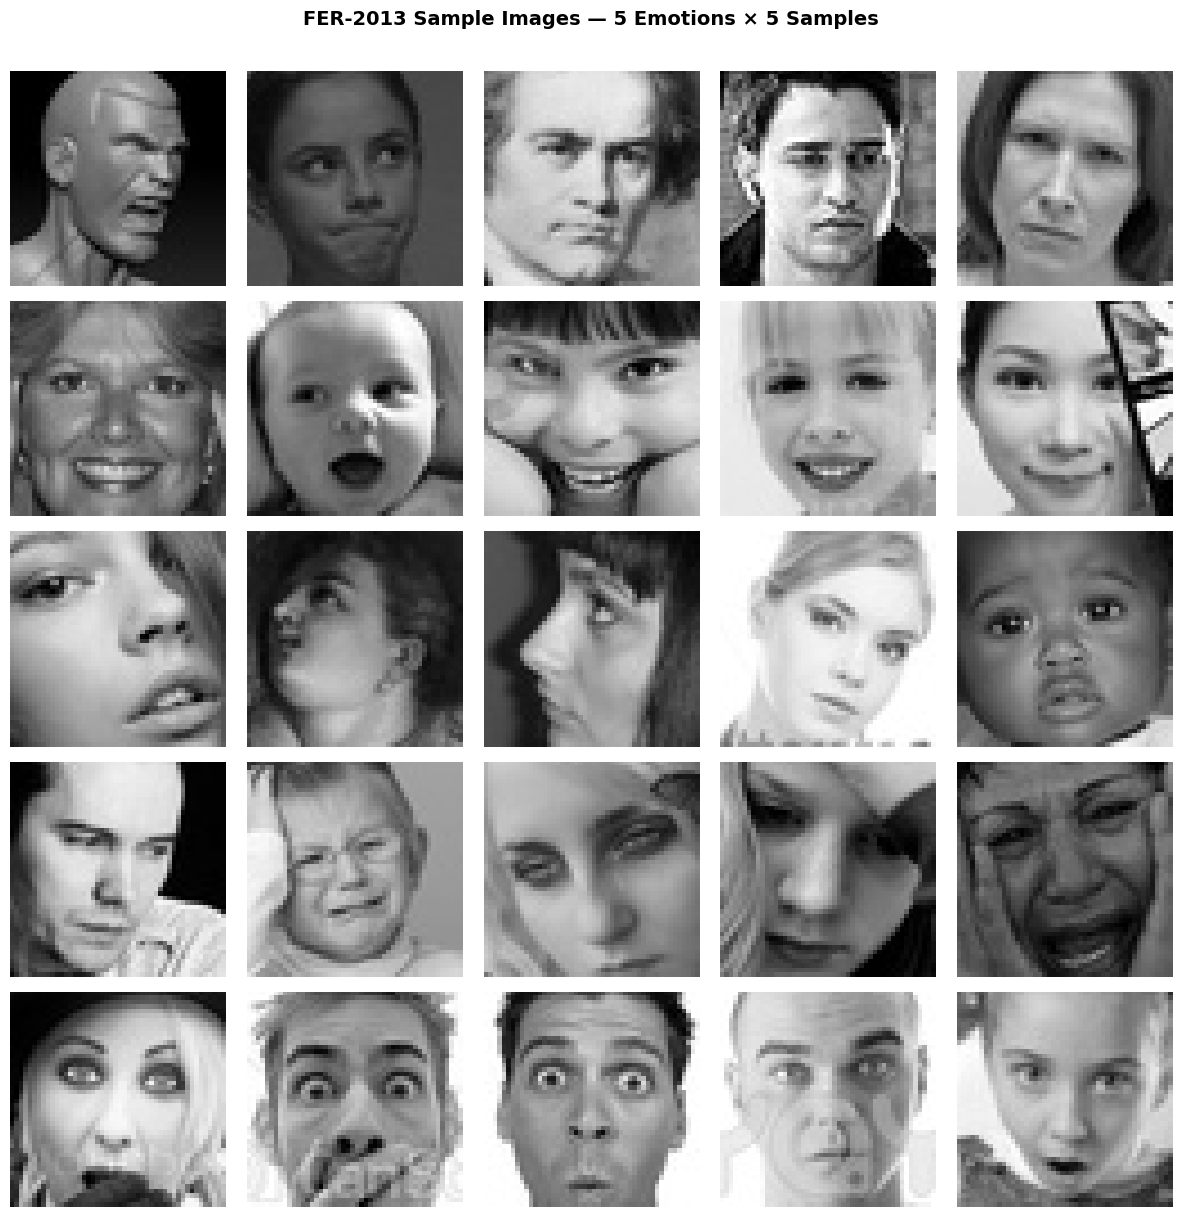

Saved: 01_sample_grid.png


In [10]:
#5x5 grid — 5 random samples per emotion
import random
import matplotlib.pyplot as plt
random.seed(42)   # fix seed for reproducibility

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle("FER-2013 Sample Images — 5 Emotions × 5 Samples",
            fontsize=14, fontweight='bold', y=1.01)

for row, emotion in enumerate(EMOTIONS):
    folder  = TRAIN_DIR + emotion + "/"
    files   = os.listdir(folder)
    samples = random.sample(files, min(5, len(files)))

    for col, fname in enumerate(samples):
        path = folder + fname
        img  = cv2.imread(path)

        if img is None:
            axes[row][col].axis("off")
            continue

        # Convert BGR → RGB for correct matplotlib display
        # OpenCV loads in Blue-Green-Red order
        # matplotlib expects Red-Green-Blue order
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row][col].imshow(img_rgb, cmap='gray')
        axes[row][col].axis("off")

        # Add emotion label on leftmost column only
        if col == 0:
            axes[row][col].set_ylabel(emotion.upper(),
                                    fontsize=11, fontweight='bold', rotation=90, labelpad=10)
            axes[row][col].yaxis.set_label_position('left')

plt.tight_layout()
plt.savefig("output/01_features/01_sample_grid.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_sample_grid.png")

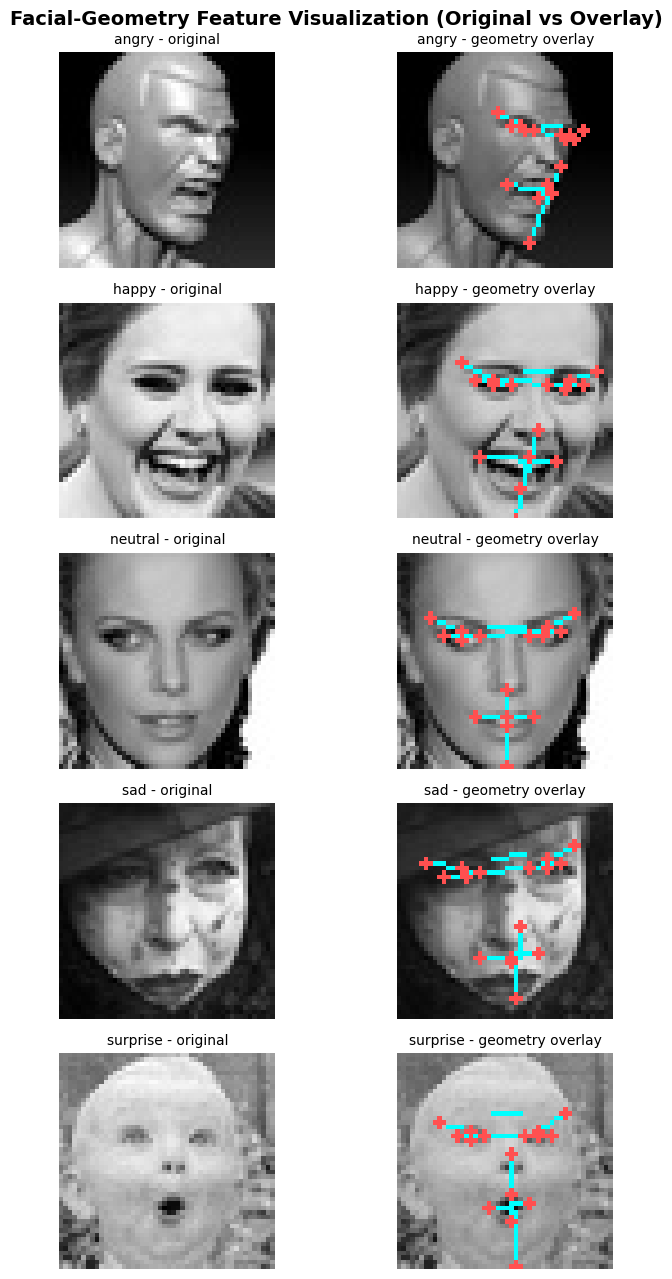

Saved -> 02_geometry_overlay_examples.png


In [28]:
# Geometry feature visualization: original image vs facial-landmark overlay
random.seed(42)

GEOM_POINTS = {
    "eye_L_outer": 33,
    "eye_L_inner": 133,
    "eye_R_inner": 362,
    "eye_R_outer": 263,
    "eye_L_top": 159,
    "eye_L_bottom": 145,
    "eye_R_top": 386,
    "eye_R_bottom": 374,
    "brow_L": 70,
    "brow_R": 300,
    "mouth_L": 61,
    "mouth_R": 291,
    "mouth_top": 13,
    "mouth_bottom": 14,
    "chin": 152,
    "nose_tip": 1,
}

GEOM_EDGES = [
    (33, 133), (362, 263),            # eye widths
    (159, 145), (386, 374),            # eye heights
    (70, 159), (300, 386),             # brow-eye distances
    (61, 291), (13, 14),               # mouth width / opening
    (1, 152),                          # nose tip to chin (jaw openness)
    (33, 263),                         # inter-ocular distance
    (55, 285),                         # inter-brow distance
]

def draw_geometry_overlay(gray, lm):
    h, w = gray.shape
    canvas = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    # Draw feature lines used by F41 geometry subset.
    for a, b in GEOM_EDGES:
        pa = (int(lm[a].x * w), int(lm[a].y * h))
        pb = (int(lm[b].x * w), int(lm[b].y * h))
        cv2.line(canvas, pa, pb, (0, 255, 255), 1)

    # Draw key landmark points.
    for idx in GEOM_POINTS.values():
        p = (int(lm[idx].x * w), int(lm[idx].y * h))
        cv2.circle(canvas, p, 1, (255, 80, 80), -1)

    return canvas

fig, axes = plt.subplots(len(EMOTIONS), 2, figsize=(8, 2.6 * len(EMOTIONS)))
fig.suptitle("Facial-Geometry Feature Visualization (Original vs Overlay)", fontsize=14, fontweight="bold")

for row, emotion in enumerate(EMOTIONS):
    folder = TRAIN_DIR + emotion + "/"
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    # Try several random samples until one face is detected.
    chosen_gray, chosen_overlay = None, None
    for fname in random.sample(files, min(len(files), 40)):
        gray = cv2.imread(folder + fname, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        gray = cv2.resize(gray, (48, 48))
        lm = _detect_landmarks(gray)
        if lm is None:
            continue
        chosen_gray = gray
        chosen_overlay = draw_geometry_overlay(gray, lm)
        break

    if chosen_gray is None:
        axes[row, 0].text(0.5, 0.5, f"{emotion}\n(no face detected)", ha="center", va="center")
        axes[row, 1].text(0.5, 0.5, f"{emotion}\n(no face detected)", ha="center", va="center")
        axes[row, 0].axis("off")
        axes[row, 1].axis("off")
        continue

    axes[row, 0].imshow(chosen_gray, cmap="gray")
    axes[row, 0].set_title(f"{emotion} - original", fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(chosen_overlay)
    axes[row, 1].set_title(f"{emotion} - geometry overlay", fontsize=10)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("output/01_features/02_geometry_overlay_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> 02_geometry_overlay_examples.png")

In [29]:
# ── Build CSV ────────────────────────────────────────
def build_csv(split_dir, out_csv, max_per_class=None):
    """
    Walk  split_dir/<emotion>/*.jpg  →  CSV with 41 features + label.
    NaN from missed MediaPipe detections are filled with column median.
    """
    records = []
    nan_imgs = []

    for emo in EMOTIONS:
        emo_dir = os.path.join(split_dir, emo)
        if not os.path.isdir(emo_dir):
            print(f"Missing folder: {emo_dir}")
            continue

        files = sorted(os.listdir(emo_dir))
        if max_per_class:
            files = files[:max_per_class]

        for fname in tqdm(files, desc=f"{emo:<10}", ncols=70):
            fpath = os.path.join(emo_dir, fname)
            gray  = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue
            feats = extract_features(gray)
            if any(np.isnan(v) for v in feats[24:]):
                nan_imgs.append(fpath)
            records.append(feats + [emo])

    df = pd.DataFrame(records, columns=FEATURE_NAMES + ["label"])

    # ── NaN fill ─────────────────────────────────────────────
    nan_total = df[FEATURE_NAMES].isna().sum().sum()
    if nan_total > 0:
        medians = df[FEATURE_NAMES].median()
        df[FEATURE_NAMES] = df[FEATURE_NAMES].fillna(medians)
        print(f"\n  Filled {nan_total} NaN values with column medians")
        print(f"  ({len(nan_imgs)} images had no detected face)")

    df.to_csv(out_csv, index=False)
    print(f"\nSaved: {out_csv}  {df.shape}")
    return df

df_train = build_csv(TRAIN_DIR, "csv/features_train_F41.csv")
df_test  = build_csv(TEST_DIR,  "csv/features_test_F41.csv")

surprise  : 100%|████████████████| 3171/3171 [00:27<00:00, 113.68it/s]



  Filled 40919 NaN values with column medians
  (2407 images had no detected face)

Saved: csv/features_train_F41.csv  (24176, 42)


surprise  : 100%|██████████████████| 831/831 [00:08<00:00, 100.96it/s]



  Filled 10319 NaN values with column medians
  (607 images had no detected face)

Saved: csv/features_test_F41.csv  (6043, 42)


In [18]:
# ── Validate CSVs ────────────────────────────────────
def validate_csv(csv_path, expected_rows_min=None):
    df = pd.read_csv(csv_path)
    print(f"\n── Validating {csv_path} ──────────────────────────")
    print(f"  Shape          : {df.shape}")

    # Column count
    assert df.shape[1] == 42,         f"Expected 42 cols (41 + label), got {df.shape[1]}"

    # No NaN
    nan_count = df[FEATURE_NAMES].isna().sum().sum()
    assert nan_count == 0, f"{nan_count} NaN values remain!"

    # Labels
    labels = set(df["label"].unique())
    assert labels == set(EMOTIONS), f"Unexpected labels: {labels}"

    # Row count
    if expected_rows_min:
        assert len(df) >= expected_rows_min,             f"Too few rows: {len(df)} < {expected_rows_min}"

    # Class distribution
    print("  Class counts:")
    for emo, cnt in df["label"].value_counts().sort_index().items():
        print(f"    {emo:<10}: {cnt:>5}")

    print("\nValidation passed")
    return df


df_train = validate_csv("csv/features_train_F41.csv", expected_rows_min=24000)
df_test  = validate_csv("csv/features_test_F41.csv",  expected_rows_min=5900)


── Validating csv/features_train_F41.csv ──────────────────────────
  Shape          : (24176, 42)
  Class counts:
    angry     :  3995
    happy     :  7215
    neutral   :  4965
    sad       :  4830
    surprise  :  3171

Validation passed

── Validating csv/features_test_F41.csv ──────────────────────────
  Shape          : (6043, 42)
  Class counts:
    angry     :   958
    happy     :  1774
    neutral   :  1233
    sad       :  1247
    surprise  :   831

Validation passed


In [17]:
# ── Summary ─────────────────────────────────────────
print("\n══ F41 Feature Summary ══════════════════════")
print(f"  Total features : {len(FEATURE_NAMES)}")
print(f"  Base (F01–F24) : 2 pixel + 16 HOG + 6 LBP")
print(f"  Geo  (F25–F41) : 17 MediaPipe FaceMesh features")
print()
groups = {
    "Eyes"  : ["ear_L","ear_R"],
    "Brows" : ["brow_eye_L","brow_eye_R","inter_brow","brow_raise_L","brow_raise_R"],
    "Mouth" : ["MAR","lip_pull","lip_droop","mouth_curl","lip_tight","jaw_open"],
    "Cheeks": ["cheek_L","cheek_R"],
    "Other" : ["nose_lip","face_AR"],
}
for grp, feats in groups.items():
    print(f"  {grp:<8}: {feats}")
print()


══ F41 Feature Summary ══════════════════════
  Total features : 41
  Base (F01–F24) : 2 pixel + 16 HOG + 6 LBP
  Geo  (F25–F41) : 17 MediaPipe FaceMesh features

  Eyes    : ['ear_L', 'ear_R']
  Brows   : ['brow_eye_L', 'brow_eye_R', 'inter_brow', 'brow_raise_L', 'brow_raise_R']
  Mouth   : ['MAR', 'lip_pull', 'lip_droop', 'mouth_curl', 'lip_tight', 'jaw_open']
  Cheeks  : ['cheek_L', 'cheek_R']
  Other   : ['nose_lip', 'face_AR']

